In [ ]:
!pip install

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

ERROR: You must give at least one requirement to install (see "pip help install")


In [ ]:
from google.colab import drive

file_path = "/content/drive/MyDrive/FIAP/Tech Challenge 5/BASE DE DADOS PEDE 2024 - DATATHON.xlsx"

xls = pd.ExcelFile(file_path)
print("Abas encontradas:", xls.sheet_names)

df_2022 = xls.parse('PEDE2022')
df_2023 = xls.parse('PEDE2023')
df_2024 = xls.parse('PEDE2024')

for nome, df in [('2022', df_2022), ('2023', df_2023), ('2024', df_2024)]:
    print(f"\n=== {nome} ===")
    print("Shape:", df.shape)
    print("Alunos únicos (RA):", df['RA'].nunique())

Abas encontradas: ['PEDE2022', 'PEDE2023', 'PEDE2024']

=== 2022 ===
Shape: (860, 42)
Alunos únicos (RA): 860

=== 2023 ===
Shape: (1014, 48)
Alunos únicos (RA): 1014

=== 2024 ===
Shape: (1156, 50)
Alunos únicos (RA): 1156


In [ ]:
for nome, df in [('2022', df_2022), ('2023', df_2023), ('2024', df_2024)]:
    print(f"\n=== Colunas {nome} ({len(df.columns)}) ===")
    print(list(df.columns))


=== Colunas 2022 (42) ===
['RA', 'Fase', 'Turma', 'Nome', 'Ano nasc', 'Idade 22', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'INDE 22', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'Rec Psicologia', 'IDA', 'Matem', 'Portug', 'Inglês', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase ideal', 'Defas', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV']

=== Colunas 2023 (48) ===
['RA', 'Fase', 'INDE 2023', 'Pedra 2023', 'Turma', 'Nome Anonimizado', 'Data de Nasc', 'Idade', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23', 'INDE 22', 'INDE 23', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'IPP', 'Rec Psicologia', 'IDA', 'Mat', 'Por', 'Ing', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase Ideal', 'Defasa

In [ ]:
map_2022 = {
    'RA': 'RA', 'Fase': 'FASE', 'Turma': 'TURMA', 'Nome': 'NOME',
    'Idade 22': 'IDADE', 'Gênero': 'GENERO', 'Ano ingresso': 'ANO_INGRESSO',
    'Instituição de ensino': 'INSTITUICAO_ENSINO', 'INDE 22': 'INDE', 'Pedra 22': 'PEDRA',
    'Cg': 'CG', 'Cf': 'CF', 'Ct': 'CT', 'Nº Av': 'N_AVALIACOES',
    'IAA': 'IAA', 'IEG': 'IEG', 'IPS': 'IPS', 'Rec Psicologia': 'REC_PSICOLOGIA',
    'IDA': 'IDA', 'Matem': 'NOTA_MAT', 'Portug': 'NOTA_POR', 'Inglês': 'NOTA_ING',
    'Indicado': 'INDICADO_BOLSA', 'Atingiu PV': 'ATINGIU_PV', 'IPV': 'IPV', 'IAN': 'IAN',
    'Fase ideal': 'FASE_IDEAL', 'Defas': 'DEFASAGEM',
    'Destaque IEG': 'DESTAQUE_IEG', 'Destaque IDA': 'DESTAQUE_IDA', 'Destaque IPV': 'DESTAQUE_IPV',
}

map_2023 = {
    'RA': 'RA', 'Fase': 'FASE', 'Turma': 'TURMA', 'Nome Anonimizado': 'NOME',
    'Idade': 'IDADE', 'Gênero': 'GENERO', 'Ano ingresso': 'ANO_INGRESSO',
    'Instituição de ensino': 'INSTITUICAO_ENSINO', 'INDE 2023': 'INDE', 'Pedra 2023': 'PEDRA',
    'Cg': 'CG', 'Cf': 'CF', 'Ct': 'CT', 'Nº Av': 'N_AVALIACOES',
    'IAA': 'IAA', 'IEG': 'IEG', 'IPS': 'IPS', 'IPP': 'IPP', 'Rec Psicologia': 'REC_PSICOLOGIA',
    'IDA': 'IDA', 'Mat': 'NOTA_MAT', 'Por': 'NOTA_POR', 'Ing': 'NOTA_ING',
    'Indicado': 'INDICADO_BOLSA', 'Atingiu PV': 'ATINGIU_PV', 'IPV': 'IPV', 'IAN': 'IAN',
    'Fase Ideal': 'FASE_IDEAL', 'Defasagem': 'DEFASAGEM',
    'Destaque IEG': 'DESTAQUE_IEG', 'Destaque IDA': 'DESTAQUE_IDA', 'Destaque IPV': 'DESTAQUE_IPV',
}

map_2024 = {
    'RA': 'RA', 'Fase': 'FASE', 'Turma': 'TURMA', 'Nome Anonimizado': 'NOME',
    'Idade': 'IDADE', 'Gênero': 'GENERO', 'Ano ingresso': 'ANO_INGRESSO',
    'Instituição de ensino': 'INSTITUICAO_ENSINO', 'Escola': 'INSTITUICAO_ENSINO_2',
    'INDE 2024': 'INDE', 'Pedra 2024': 'PEDRA',
    'Cg': 'CG', 'Cf': 'CF', 'Ct': 'CT', 'Nº Av': 'N_AVALIACOES',
    'IAA': 'IAA', 'IEG': 'IEG', 'IPS': 'IPS', 'IPP': 'IPP', 'Rec Psicologia': 'REC_PSICOLOGIA',
    'IDA': 'IDA', 'Mat': 'NOTA_MAT', 'Por': 'NOTA_POR', 'Ing': 'NOTA_ING',
    'Indicado': 'INDICADO_BOLSA', 'Atingiu PV': 'ATINGIU_PV', 'IPV': 'IPV', 'IAN': 'IAN',
    'Fase Ideal': 'FASE_IDEAL', 'Defasagem': 'DEFASAGEM',
    'Destaque IEG': 'DESTAQUE_IEG', 'Destaque IDA': 'DESTAQUE_IDA', 'Destaque IPV': 'DESTAQUE_IPV',
    'Ativo/ Inativo': 'ATIVO_INATIVO',
}

In [ ]:
def padronizar(df, mapping, ano):
    _df = df.rename(columns=mapping)
    colunas_padrao = list(dict.fromkeys(mapping.values()))
    colunas_existentes = [c for c in colunas_padrao if c in _df.columns]
    _df = _df[colunas_existentes].copy()
    _df['ANO'] = ano
    return _df

d22 = padronizar(df_2022, map_2022, 2022)
d23 = padronizar(df_2023, map_2023, 2023)
d24 = padronizar(df_2024, map_2024, 2024)

df_long = pd.concat([d22, d23, d24], ignore_index=True, sort=False)

print("Shape final:", df_long.shape)
print("Alunos únicos (RA):", df_long['RA'].nunique())
print("Registros por ano:\n", df_long['ANO'].value_counts())
df_long.head()

Shape final: (3030, 35)
Alunos únicos (RA): 1661
Registros por ano:
 ANO
2024    1156
2023    1014
2022     860
Name: count, dtype: int64


,RA,FASE,TURMA,NOME,IDADE,GENERO,ANO_INGRESSO,INSTITUICAO_ENSINO,INDE,PEDRA,CG,CF,CT,N_AVALIACOES,IAA,IEG,IPS,REC_PSICOLOGIA,IDA,NOTA_MAT,NOTA_POR,NOTA_ING,INDICADO_BOLSA,ATINGIU_PV,IPV,IAN,FASE_IDEAL,DEFASAGEM,DESTAQUE_IEG,DESTAQUE_IDA,DESTAQUE_IPV,ANO,IPP,INSTITUICAO_ENSINO_2,ATIVO_INATIVO
0,RA-1,7,A,Aluno-1,19,Menina,2016,Escola Pública,5.783,Quartzo,753.0,18.0,10.0,4.0,8.3,4.1,5.6,Requer avaliação,4.0,2.7,3.5,6.0,Sim,Não,7.278,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN
1,RA-2,7,A,Aluno-2,17,Menina,2017,Rede Decisão,7.055,Ametista,469.0,8.0,3.0,4.0,8.8,5.2,6.3,Sem limitações,6.8,6.3,4.5,9.7,Não,Não,6.778,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN
2,RA-3,7,A,Aluno-3,17,Menina,2016,Rede Decisão,6.591,Ágata,629.0,13.0,6.0,4.0,0.0,7.9,5.6,Sem limitações,5.6,5.8,4.0,6.9,Não,Não,7.556,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...,2022,NaN,NaN,NaN
3,RA-4,7,A,Aluno-4,17,Menino,2017,Rede Decisão,5.951,Quartzo,731.0,15.0,7.0,4.0,8.8,4.5,5.6,Requer avaliação,5.0,2.8,3.5,8.7,Não,Não,5.278,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN
4,RA-5,7,A,Aluno-5,17,Menina,2016,Rede Decisão,7.427,Ametista,344.0,6.0,2.0,4.0,7.9,8.6,5.6,Requer avaliação,5.2,7.0,2.9,5.7,Não,Não,7.389,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN


In [ ]:
df_long['PEDRA'] = df_long['PEDRA'].replace({'Agata': 'Ágata', 'INCLUIR': np.nan})

df_long['GENERO'] = df_long['GENERO'].replace({
    'Menina': 'Feminino', 'Menino': 'Masculino'})


df_long['FASE_IDEAL'] = (
    df_long['FASE_IDEAL']
    .astype(str)
    .str.extract(r'(\d+)')
    .astype(float))

df_long['FASE'] = pd.to_numeric(df_long['FASE'], errors='coerce')

for col in ['ATINGIU_PV', 'INDICADO_BOLSA']:
    df_long[col] = df_long[col].map({'Sim': True, 'Não': False})

print(df_long['PEDRA'].value_counts(dropna=False))
print(df_long['GENERO'].value_counts(dropna=False))
print(df_long[['FASE', 'FASE_IDEAL']].describe())

PEDRA
Ametista    1120
Ágata        721
Topázio      688
Quartzo      316
NaN          185
Name: count, dtype: int64
GENERO
Feminino     1626
Masculino    1404
Name: count, dtype: int64
             FASE   FASE_IDEAL
count  898.000000  3030.000000
mean     2.390869     3.303630
std      2.235271     2.059903
min      0.000000     1.000000
25%      1.000000     2.000000
50%      2.000000     3.000000
75%      3.000000     4.000000
max      9.000000     8.000000


In [ ]:
nulos = df_long.isna().sum().sort_values(ascending=False)
percentual = (nulos / len(df_long) * 100).round(1)
resumo_nulos = pd.DataFrame({'qtd_nulos': nulos, 'pct_nulos': percentual})
resumo_nulos[resumo_nulos['qtd_nulos'] > 0]

,qtd_nulos,pct_nulos
CT,2170,71.6
REC_PSICOLOGIA,2170,71.6
CG,2170,71.6
DESTAQUE_IPV,2170,71.6
DESTAQUE_IDA,2170,71.6
ATINGIU_PV,2170,71.6
CF,2170,71.6
DESTAQUE_IEG,2170,71.6
INDICADO_BOLSA,2170,71.6
FASE,2132,70.4


In [ ]:
def extrair_fase(valor):
    if pd.isna(valor):
        return np.nan
    s = str(valor).strip().upper()
    if s == 'ALFA':
        return 0
    match = pd.Series([s]).str.extract(r'(\d+)')[0][0]
    return float(match) if match is not None else np.nan

df_long.loc[df_long['ANO'] == 2022, 'FASE'] = df_2022['Fase'].values
df_long.loc[df_long['ANO'] == 2023, 'FASE'] = df_2023['Fase'].apply(extrair_fase).values
df_long.loc[df_long['ANO'] == 2024, 'FASE'] = df_2024['Fase'].apply(extrair_fase).values

df_long['FASE'] = pd.to_numeric(df_long['FASE'], errors='coerce')

print(df_long.groupby('ANO')['FASE'].apply(lambda s: s.isna().sum()))
print(df_long['FASE'].value_counts(dropna=False).sort_index())

ANO
2022    0
2023    0
2024    0
Name: FASE, dtype: int64
FASE
0.0    617
1.0    550
2.0    540
3.0    491
4.0    285
5.0    225
6.0     76
7.0     81
8.0    127
9.0     38
Name: count, dtype: int64


In [ ]:
df_long['DEFASAGEM'] = pd.to_numeric(df_long['DEFASAGEM'], errors='coerce')

colunas_so_2022 = ['CG', 'CF', 'CT', 'REC_PSICOLOGIA', 'ATINGIU_PV', 'INDICADO_BOLSA',
                    'DESTAQUE_IEG', 'DESTAQUE_IDA', 'DESTAQUE_IPV']

print("Confirmando que são exclusivas de 2022:")
print(df_long[df_long['ANO'] != 2022][colunas_so_2022].notna().sum())

df_long.to_csv('/content/drive/MyDrive/FIAP/Tech Challenge 5/Datathon/df_long_consolidado.csv', index=False)
print("\nShape final:", df_long.shape)
df_long.sample(5)

Confirmando que são exclusivas de 2022:
CG                0
CF                0
CT                0
REC_PSICOLOGIA    0
ATINGIU_PV        0
INDICADO_BOLSA    0
DESTAQUE_IEG      0
DESTAQUE_IDA      0
DESTAQUE_IPV      0
dtype: int64

Shape final: (3030, 35)


,RA,FASE,TURMA,NOME,IDADE,GENERO,ANO_INGRESSO,INSTITUICAO_ENSINO,INDE,PEDRA,CG,CF,CT,N_AVALIACOES,IAA,IEG,IPS,REC_PSICOLOGIA,IDA,NOTA_MAT,NOTA_POR,NOTA_ING,INDICADO_BOLSA,ATINGIU_PV,IPV,IAN,FASE_IDEAL,DEFASAGEM,DESTAQUE_IEG,DESTAQUE_IDA,DESTAQUE_IPV,ANO,IPP,INSTITUICAO_ENSINO_2,ATIVO_INATIVO
2793,RA-1603,5.0,5C,Aluno-1603,16,Feminino,2024,Pública,7.836519,Ametista,NaN,NaN,NaN,4.0,7.500,9.259259,7.51,NaN,8.333333,8.5,7.0,9.5,NaN,NaN,7.835,5.0,6.0,-1,NaN,NaN,NaN,2024,7.500,EE Olivia de Faria Nogueira,Cursando
1707,RA-108,5.0,5B,Aluno-108,1900-01-17 00:00:00,Feminino,2019,Concluiu o 3º EM,4.9308,Quartzo,NaN,NaN,NaN,4.0,5.800,7.300000,2.52,NaN,2.900000,2.7,3.2,2.8,NaN,NaN,5.590,5.0,7.0,-2,NaN,NaN,NaN,2023,4.375,NaN,NaN
16,RA-17,7.0,D,Aluno-17,20,Masculino,2022,Escola Pública,8.068,Topázio,125.0,2.0,1.0,4.0,8.800,10.000000,7.50,Não atendido,7.800000,9.0,6.5,NaN,True,False,8.292,5.0,8.0,-1,Destaque: A sua boa entrega das lições de casa.,Destaque: As suas boas notas na Passos Mágicos.,Destaque: A sua boa integração aos Princípios ...,2022,NaN,NaN,NaN
2775,RA-1198,5.0,5A,Aluno-1198,17,Feminino,2023,Pública,6.921775,Ágata,NaN,NaN,NaN,5.0,8.751,9.458874,7.51,NaN,3.500000,0.0,1.0,9.5,NaN,NaN,7.332,5.0,6.0,-1,NaN,NaN,NaN,2024,7.375,EE Joaquim Mendes Feliz,Cursando
2704,RA-388,4.0,4F,Aluno-388,16,Feminino,2021,Pública,5.965308,Quartzo,NaN,NaN,NaN,5.0,7.500,6.349206,7.51,NaN,4.333333,1.0,7.0,5.0,NaN,NaN,5.764,5.0,5.0,-1,NaN,NaN,NaN,2024,6.750,EE Joaquim Mendes Feliz,Cursando


In [ ]:
import datetime

def fix_idade(val):
    if isinstance(val, (datetime.datetime, datetime.date, pd.Timestamp)):
        return (pd.Timestamp(val) - pd.Timestamp('1899-12-30')).days
    return val

df_long.loc[df_long['ANO'] == 2023, 'IDADE'] = df_2023['Idade'].apply(fix_idade).values
df_long.loc[df_long['ANO'] == 2024, 'IDADE'] = df_2024['Idade'].apply(fix_idade).values

df_long['IDADE'] = pd.to_numeric(df_long['IDADE'], errors='coerce')

print(df_long.groupby('ANO')['IDADE'].describe())

       count       mean       std  min   25%   50%   75%   max
ANO                                                           
2022   860.0  12.138372  2.771998  7.0  10.0  12.0  14.0  21.0
2023  1014.0  12.724852  3.354982  7.0  10.0  12.0  15.0  27.0
2024  1156.0  12.987889  3.584699  7.0  10.0  12.0  15.0  27.0


In [ ]:
df_long.to_csv('/content/drive/MyDrive/FIAP/Tech Challenge 5/Datathon/df_long_consolidado.csv', index=False)
print("Checkpoint salvo. Shape final:", df_long.shape)

Checkpoint salvo. Shape final: (3030, 35)


In [ ]:
# Classificação de defasagem conforme a lógica do indicador:
# DEFASAGEM = 0  -> adequado ao nível
# DEFASAGEM < 0  -> defasado (quanto mais negativo, mais severo)
# DEFASAGEM > 0  -> à frente do nível esperado

def classificar_defasagem(d):
    if pd.isna(d):
        return np.nan
    if d == 0:
        return 'Adequado'
    elif d == -1:
        return 'Levemente defasado'
    elif d <= -2:
        return 'Moderada/Severamente defasado'
    else:
        return 'À frente do nível'

df_long['CLASSIF_DEFASAGEM'] = df_long['DEFASAGEM'].apply(classificar_defasagem)

tabela_defasagem = pd.crosstab(df_long['ANO'], df_long['CLASSIF_DEFASAGEM'], normalize='index') * 100
print("Percentual por ano:")
print(tabela_defasagem.round(1))

print("\nContagem absoluta por ano:")
print(pd.crosstab(df_long['ANO'], df_long['CLASSIF_DEFASAGEM']))

# Estatísticas descritivas do IAN por ano
print("\nIAN por ano:")
print(df_long.groupby('ANO')['IAN'].describe())

Percentual por ano:
CLASSIF_DEFASAGEM  Adequado  Levemente defasado  Moderada/Severamente defasado  À frente do nível
ANO                                                                                              
2022                   28.7                47.7                           22.2                1.4
2023                   41.4                40.2                           14.2                4.1
2024                   42.0                38.1                            8.0               11.9

Contagem absoluta por ano:
CLASSIF_DEFASAGEM  Adequado  Levemente defasado  Moderada/Severamente defasado  À frente do nível
ANO                                                                                              
2022                    247                 410                            191                 12
2023                    420                 408                            144                 42
2024                    485                 441                       

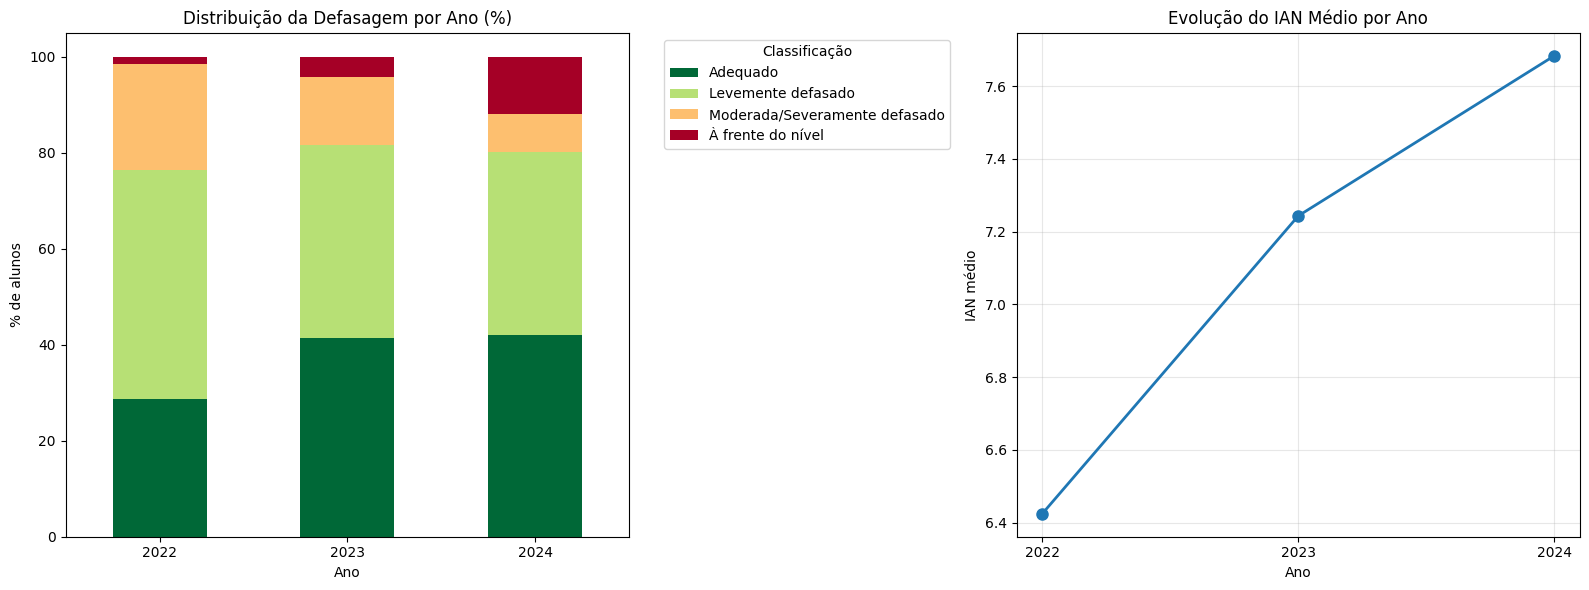

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: distribuição percentual de classificação de defasagem por ano
tabela_defasagem.plot(kind='bar', stacked=True, ax=axes[0], colormap='RdYlGn_r')
axes[0].set_title('Distribuição da Defasagem por Ano (%)')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('% de alunos')
axes[0].legend(title='Classificação', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=0)

# Gráfico 2: evolução do IAN médio
ian_medio = df_long.groupby('ANO')['IAN'].mean()
axes[1].plot(ian_medio.index, ian_medio.values, marker='o', linewidth=2, markersize=8)
axes[1].set_title('Evolução do IAN Médio por Ano')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('IAN médio')
axes[1].set_xticks(ian_medio.index)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("IDA por ano:")
print(df_long.groupby('ANO')['IDA'].describe())

print("\nNotas por disciplina, por ano:")
print(df_long.groupby('ANO')[['NOTA_MAT', 'NOTA_POR', 'NOTA_ING']].mean().round(2))

from scipy import stats
ida_2022 = df_long[df_long['ANO'] == 2022]['IDA'].dropna()
ida_2023 = df_long[df_long['ANO'] == 2023]['IDA'].dropna()
ida_2024 = df_long[df_long['ANO'] == 2024]['IDA'].dropna()

f_stat, p_value = stats.f_oneway(ida_2022, ida_2023, ida_2024)
print(f"\nANOVA IDA entre anos: F={f_stat:.2f}, p-valor={p_value:.4f}")

IDA por ano:
       count      mean       std  min       25%   50%  75%   max
ANO                                                             
2022   860.0  6.092907  2.046209  0.0  4.800000  6.30  7.6   9.9
2023   937.0  6.663394  1.595277  0.0  5.700000  6.80  7.9  10.0
2024  1055.0  6.351422  2.131639  0.0  4.916667  6.75  8.0  10.0

Notas por disciplina, por ano:
      NOTA_MAT  NOTA_POR  NOTA_ING
ANO                               
2022      5.81      6.32      5.88
2023      6.41      6.82      6.20
2024      6.23      6.18      6.60

ANOVA IDA entre anos: F=19.44, p-valor=0.0000


/tmp/ipykernel_3804/1996246251.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_long, x='ANO', y='IDA', ax=axes[0], palette='Blues')


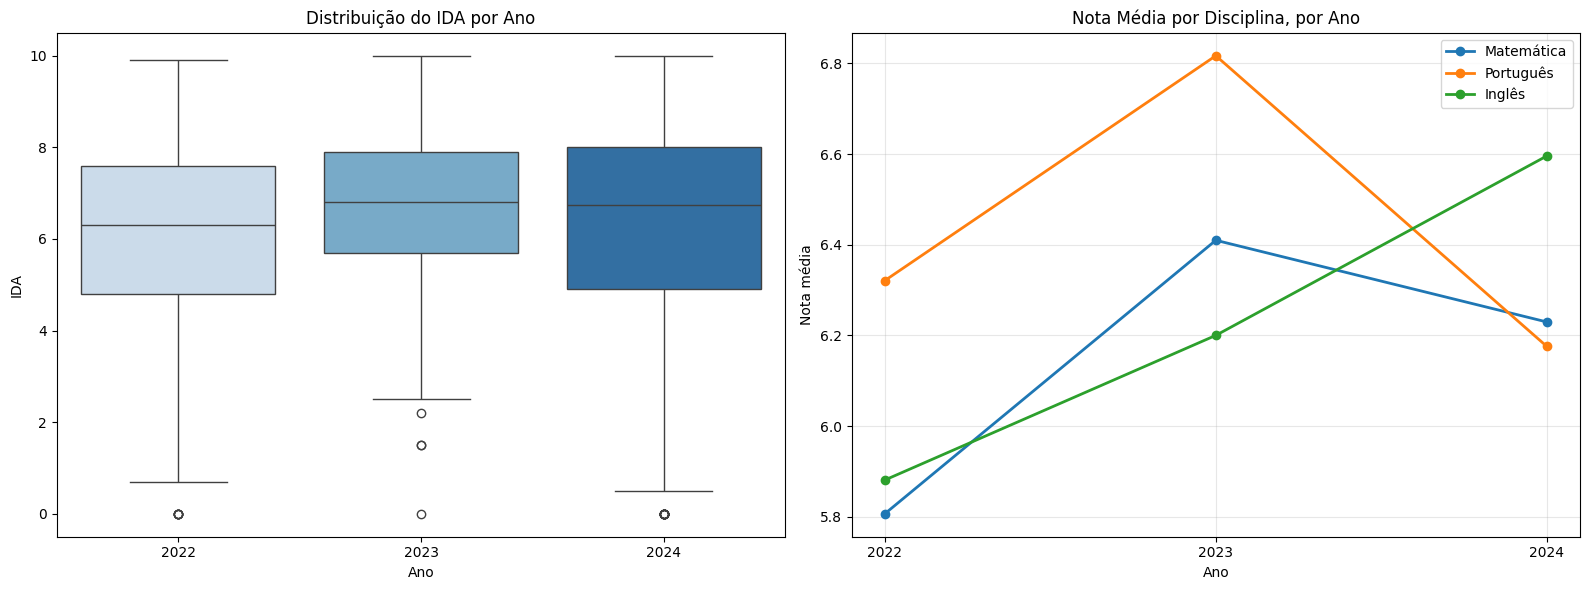

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: IDA médio com desvio padrão (boxplot mostra melhor a dispersão)
sns.boxplot(data=df_long, x='ANO', y='IDA', ax=axes[0], palette='Blues')
axes[0].set_title('Distribuição do IDA por Ano')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('IDA')

# Gráfico 2: evolução das notas por disciplina
notas_ano = df_long.groupby('ANO')[['NOTA_MAT', 'NOTA_POR', 'NOTA_ING']].mean()
notas_ano.plot(marker='o', ax=axes[1], linewidth=2)
axes[1].set_title('Nota Média por Disciplina, por Ano')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Nota média')
axes[1].set_xticks(notas_ano.index)
axes[1].legend(['Matemática', 'Português', 'Inglês'])
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
colunas_indicadores = ['INDE', 'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV',
                        'CG', 'CF', 'CT', 'N_AVALIACOES', 'NOTA_MAT', 'NOTA_POR', 'NOTA_ING']

for col in colunas_indicadores:
    df_long[col] = pd.to_numeric(df_long[col], errors='coerce')

print("Nulos após conversão forçada:")
print(df_long[colunas_indicadores].isna().sum())

Nulos após conversão forçada:
INDE             185
IAN                0
IDA              178
IEG               76
IAA              165
IPS              171
IPP             1038
IPV              178
CG              2170
CF              2170
CT              2170
N_AVALIACOES      76
NOTA_MAT         184
NOTA_POR         185
NOTA_ING        1939
dtype: int64


In [ ]:
from scipy.stats import pearsonr

cols_correlacao = ['IEG', 'IDA', 'IPV', 'IAN', 'IAA', 'IPS', 'INDE']
corr_df = df_long[cols_correlacao].corr()
print(corr_df.round(2))

# Testando significância estatística das correlações
for par in [('IEG', 'IDA'), ('IEG', 'IPV')]:
    subset = df_long[[par[0], par[1]]].dropna()
    r, p = pearsonr(subset[par[0]], subset[par[1]])
    print(f"\n{par[0]} x {par[1]}: r={r:.3f}, p-valor={p:.4f}, n={len(subset)}")

       IEG   IDA   IPV   IAN   IAA   IPS  INDE
IEG   1.00  0.54  0.56 -0.06  0.13 -0.05  0.75
IDA   0.54  1.00  0.56  0.12  0.12  0.02  0.79
IPV   0.56  0.56  1.00  0.15  0.06 -0.05  0.72
IAN  -0.06  0.12  0.15  1.00  0.03  0.00  0.41
IAA   0.13  0.12  0.06  0.03  1.00  0.16  0.40
IPS  -0.05  0.02 -0.05  0.00  0.16  1.00  0.20
INDE  0.75  0.79  0.72  0.41  0.40  0.20  1.00

IEG x IDA: r=0.539, p-valor=0.0000, n=2852

IEG x IPV: r=0.558, p-valor=0.0000, n=2852


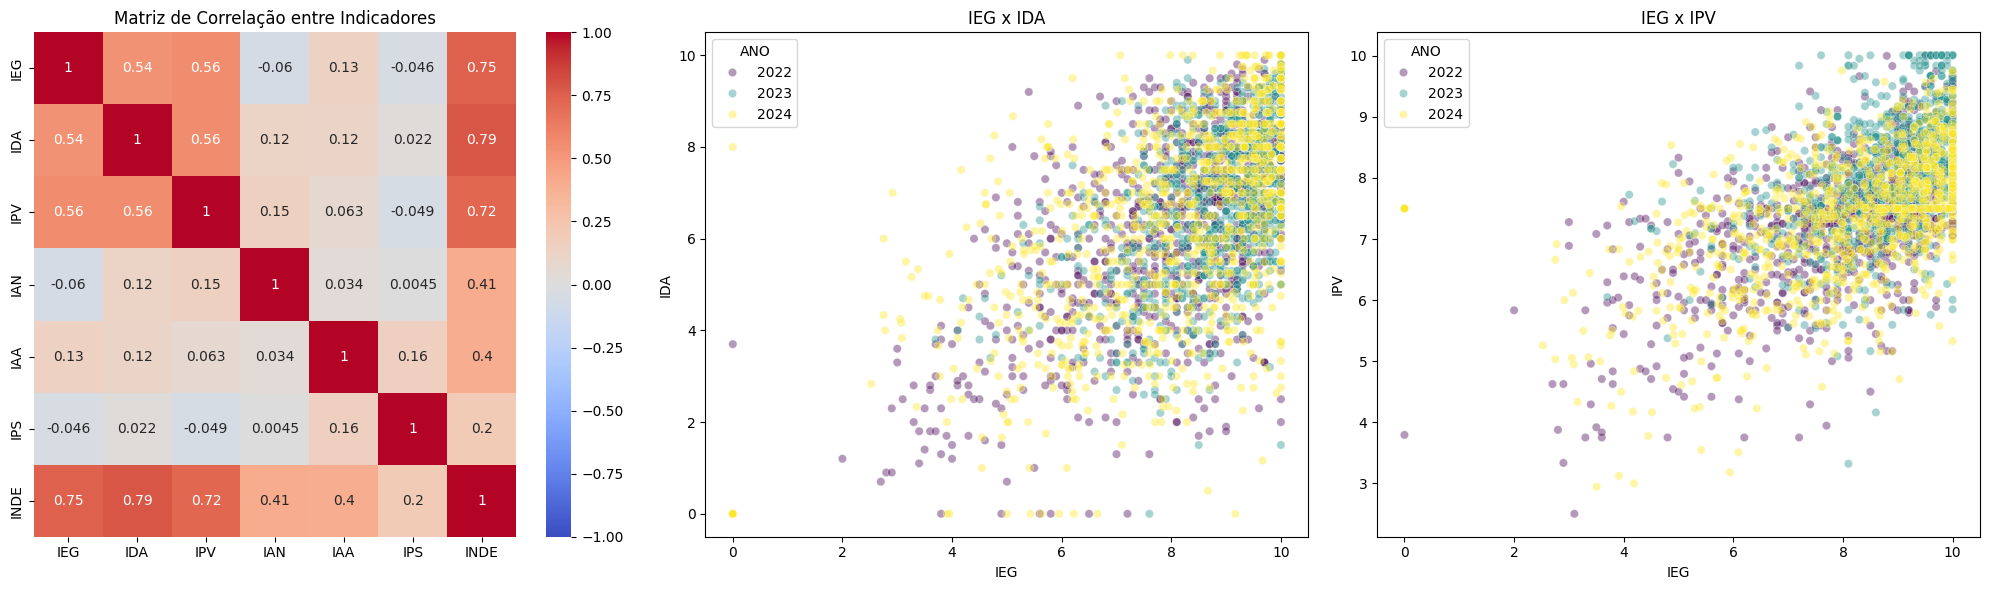

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.heatmap(corr_df, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Matriz de Correlação entre Indicadores')

sns.scatterplot(data=df_long, x='IEG', y='IDA', hue='ANO', alpha=0.4, ax=axes[1], palette='viridis')
axes[1].set_title('IEG x IDA')

sns.scatterplot(data=df_long, x='IEG', y='IPV', hue='ANO', alpha=0.4, ax=axes[2], palette='viridis')
axes[2].set_title('IEG x IPV')

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import pearsonr

for par in [('IAA', 'IDA'), ('IAA', 'IEG')]:
    subset = df_long[[par[0], par[1]]].dropna()
    r, p = pearsonr(subset[par[0]], subset[par[1]])
    print(f"{par[0]} x {par[1]}: r={r:.3f}, p-valor={p:.4f}, n={len(subset)}")

df_long['GAP_AUTOPERCEPCAO'] = df_long['IAA'] - df_long['IDA']

print("\nDistribuição do gap de autopercepção:")
print(df_long['GAP_AUTOPERCEPCAO'].describe())

superestima = (df_long['GAP_AUTOPERCEPCAO'] > 2).sum()
subestima = (df_long['GAP_AUTOPERCEPCAO'] < -2).sum()
total_valido = df_long['GAP_AUTOPERCEPCAO'].notna().sum()
print(f"\nSe superestimam (IAA > IDA + 2 pontos): {superestima} ({superestima/total_valido*100:.1f}%)")
print(f"Se subestimam (IAA < IDA - 2 pontos): {subestima} ({subestima/total_valido*100:.1f}%)")

IAA x IDA: r=0.115, p-valor=0.0000, n=2851
IAA x IEG: r=0.133, p-valor=0.0000, n=2852

Distribuição do gap de autopercepção:
count    2851.000000
mean        1.552776
std         3.080380
min        -9.900000
25%         0.400000
50%         1.800000
75%         3.400000
max         9.600000
Name: GAP_AUTOPERCEPCAO, dtype: float64

Se superestimam (IAA > IDA + 2 pontos): 1347 (47.2%)
Se subestimam (IAA < IDA - 2 pontos): 259 (9.1%)


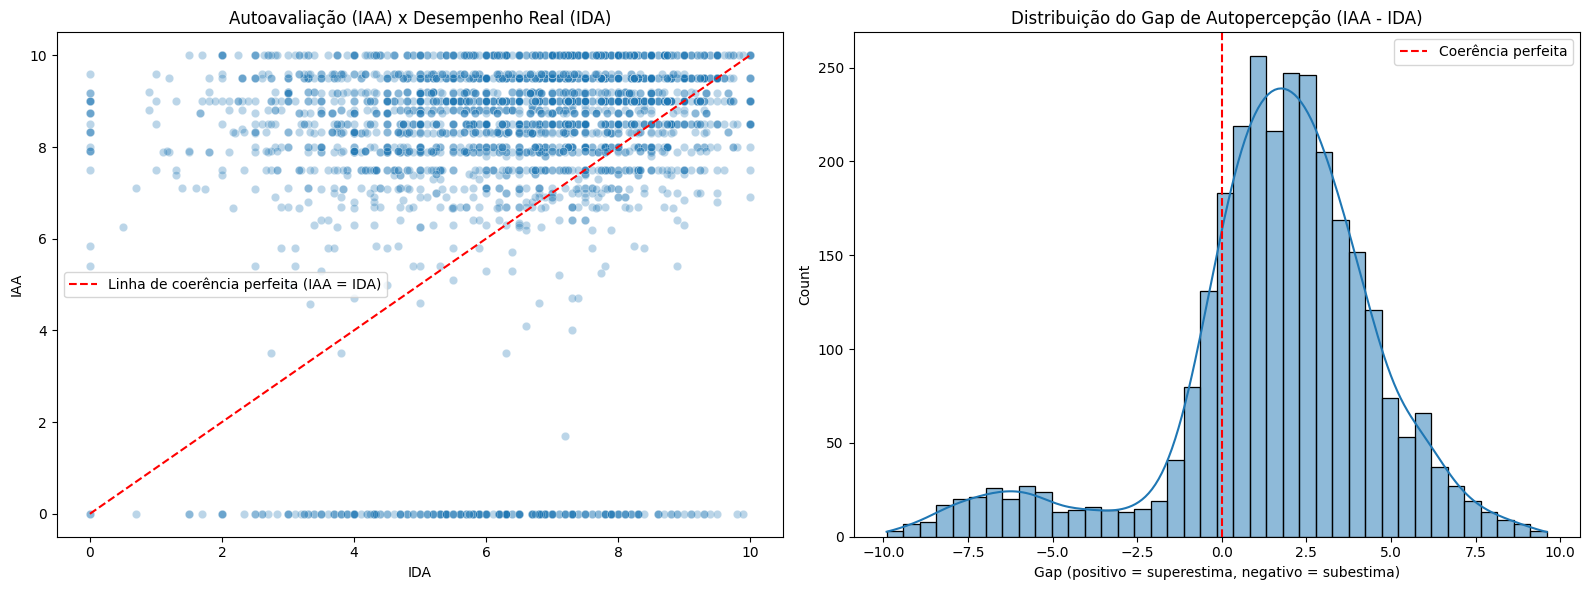

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df_long, x='IDA', y='IAA', alpha=0.3, ax=axes[0])
axes[0].plot([0, 10], [0, 10], 'r--', label='Linha de coerência perfeita (IAA = IDA)')
axes[0].set_title('Autoavaliação (IAA) x Desempenho Real (IDA)')
axes[0].legend()

sns.histplot(df_long['GAP_AUTOPERCEPCAO'].dropna(), bins=40, ax=axes[1], kde=True)
axes[1].axvline(0, color='red', linestyle='--', label='Coerência perfeita')
axes[1].set_title('Distribuição do Gap de Autopercepção (IAA - IDA)')
axes[1].set_xlabel('Gap (positivo = superestima, negativo = subestima)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
todos_ras = df_long['RA'].unique()

pivot_ips = df_long.pivot_table(index='RA', columns='ANO', values='IPS').reindex(todos_ras)
pivot_ida = df_long.pivot_table(index='RA', columns='ANO', values='IDA').reindex(todos_ras)
pivot_ieg = df_long.pivot_table(index='RA', columns='ANO', values='IEG').reindex(todos_ras)

pares = []
for ano_t, ano_t1 in [(2022, 2023), (2023, 2024)]:
    temp = pd.DataFrame({
        'RA': todos_ras,
        'IPS_t': pivot_ips[ano_t].values,
        'IDA_t': pivot_ida[ano_t].values,
        'IDA_t1': pivot_ida[ano_t1].values,
        'IEG_t': pivot_ieg[ano_t].values,
        'IEG_t1': pivot_ieg[ano_t1].values,
        'ANO_BASE': ano_t
    })
    pares.append(temp)

painel = pd.concat(pares, ignore_index=True).dropna(subset=['IPS_t'])
painel['DELTA_IDA'] = painel['IDA_t1'] - painel['IDA_t']
painel['DELTA_IEG'] = painel['IEG_t1'] - painel['IEG_t']

print("Tamanho do painel (aluno-transição):", len(painel))
print(painel[['IPS_t', 'DELTA_IDA', 'DELTA_IEG']].describe())

Tamanho do painel (aluno-transição): 1805
             IPS_t    DELTA_IDA    DELTA_IEG
count  1805.000000  1253.000000  1264.000000
mean      5.970321    -0.208832    -0.412985
std       1.904668     1.766329     1.672402
min       2.500000    -6.800000    -9.900000
25%       5.000000    -1.200000    -0.932404
50%       6.900000    -0.166667    -0.100000
75%       7.500000     0.900000     0.400000
max      10.000000     5.750000     7.800000


In [ ]:
from scipy.stats import pearsonr

for col in ['DELTA_IDA', 'DELTA_IEG']:
    subset = painel[['IPS_t', col]].dropna()
    r, p = pearsonr(subset['IPS_t'], subset[col])
    print(f"IPS(t) x {col}: r={r:.3f}, p-valor={p:.4f}, n={len(subset)}")

mediana_ips = painel['IPS_t'].median()
painel['GRUPO_IPS'] = np.where(painel['IPS_t'] < mediana_ips, 'IPS baixo', 'IPS alto')

print("\nDelta médio por grupo de IPS:")
print(painel.groupby('GRUPO_IPS')[['DELTA_IDA', 'DELTA_IEG']].mean().round(3))

print("\n% de alunos que caíram no desempenho (DELTA_IDA < 0), por grupo:")
print(painel.groupby('GRUPO_IPS')['DELTA_IDA'].apply(lambda s: (s < 0).mean() * 100).round(1))

IPS(t) x DELTA_IDA: r=0.120, p-valor=0.0000, n=1253
IPS(t) x DELTA_IEG: r=0.161, p-valor=0.0000, n=1264

Delta médio por grupo de IPS:
           DELTA_IDA  DELTA_IEG
GRUPO_IPS                      
IPS alto      -0.019     -0.158
IPS baixo     -0.398     -0.665

% de alunos que caíram no desempenho (DELTA_IDA < 0), por grupo:
GRUPO_IPS
IPS alto     35.4
IPS baixo    39.2
Name: DELTA_IDA, dtype: float64


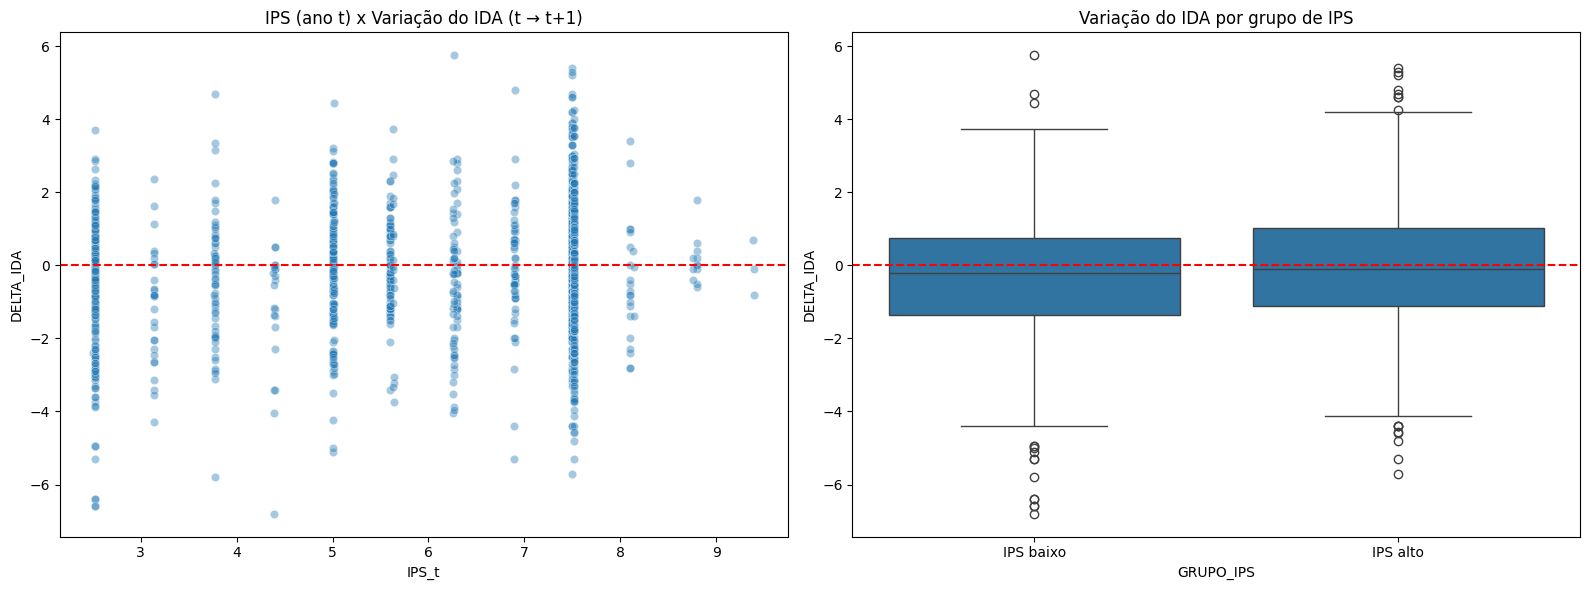

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=painel, x='IPS_t', y='DELTA_IDA', alpha=0.4, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('IPS (ano t) x Variação do IDA (t → t+1)')

sns.boxplot(data=painel, x='GRUPO_IPS', y='DELTA_IDA', ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Variação do IDA por grupo de IPS')

plt.tight_layout()
plt.show()

In [ ]:
subset_ipp = df_long[df_long['ANO'].isin([2023, 2024])].copy()

print("Cobertura de IPP:", subset_ipp['IPP'].notna().sum(), "/", len(subset_ipp))

r, p = pearsonr(subset_ipp[['IPP', 'IAN']].dropna()['IPP'], subset_ipp[['IPP', 'IAN']].dropna()['IAN'])
print(f"IPP x IAN: r={r:.3f}, p-valor={p:.4f}")

r2, p2 = pearsonr(subset_ipp[['IPP', 'DEFASAGEM']].dropna()['IPP'], subset_ipp[['IPP', 'DEFASAGEM']].dropna()['DEFASAGEM'])
print(f"IPP x DEFASAGEM: r={r2:.3f}, p-valor={p2:.4f}")

print("\nIPP médio por classificação de defasagem:")
print(subset_ipp.groupby('CLASSIF_DEFASAGEM')['IPP'].agg(['mean', 'std', 'count']).round(2))

Cobertura de IPP: 1992 / 2170
IPP x IAN: r=0.123, p-valor=0.0000
IPP x DEFASAGEM: r=0.182, p-valor=0.0000

IPP médio por classificação de defasagem:
                               mean   std  count
CLASSIF_DEFASAGEM                               
Adequado                       7.64  0.91    778
Levemente defasado             7.55  0.93    847
Moderada/Severamente defasado  7.11  1.03    237
À frente do nível              7.93  0.74    130


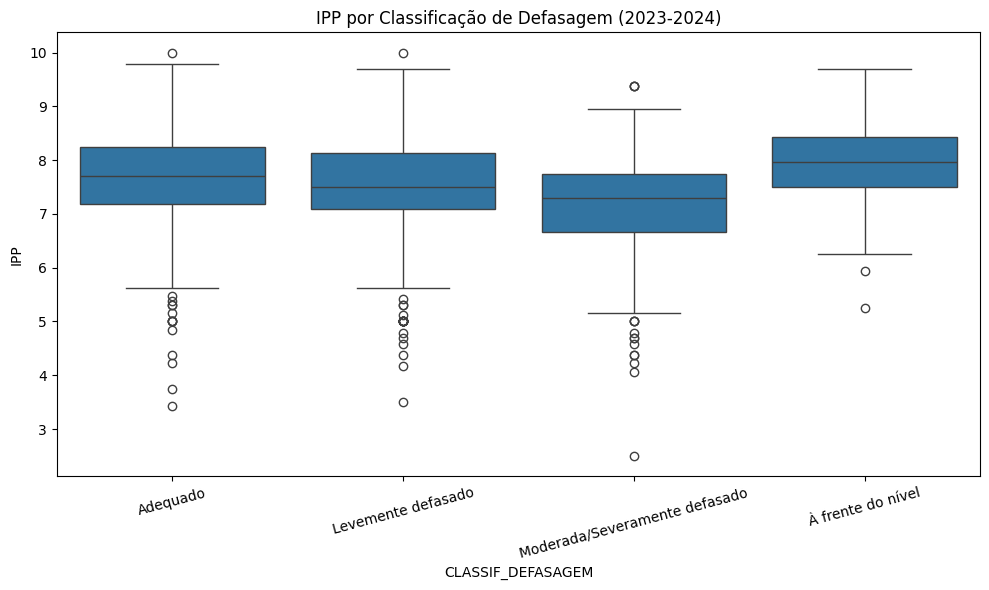

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ordem = ['Adequado', 'Levemente defasado', 'Moderada/Severamente defasado', 'À frente do nível']
sns.boxplot(data=subset_ipp, x='CLASSIF_DEFASAGEM', y='IPP', order=ordem, ax=ax)
ax.set_title('IPP por Classificação de Defasagem (2023-2024)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
indicadores_preditores = ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP']

print("Correlação de cada indicador com IPV:")
correlacoes_ipv = df_long[indicadores_preditores + ['IPV']].corr()['IPV'].drop('IPV').sort_values(ascending=False)
print(correlacoes_ipv.round(3))

# Regressão linear múltipla para ver o peso relativo (padronizado) de cada indicador sobre o IPV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

dados_reg = df_long[indicadores_preditores + ['IPV']].dropna()
X = dados_reg[indicadores_preditores]
y = dados_reg['IPV']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

modelo = LinearRegression()
modelo.fit(X_scaled, y)

coeficientes = pd.Series(modelo.coef_, index=indicadores_preditores).sort_values(ascending=False)
print(f"\nR² do modelo: {modelo.score(X_scaled, y):.3f}")
print(f"N de observações: {len(dados_reg)}")
print("\nCoeficientes padronizados (impacto relativo no IPV):")
print(coeficientes.round(3))

Correlação de cada indicador com IPV:
IPP    0.607
IEG    0.558
IDA    0.557
IAN    0.149
IAA    0.063
IPS   -0.049
Name: IPV, dtype: float64

R² do modelo: 0.531
N de observações: 1985

Coeficientes padronizados (impacto relativo no IPV):
IPP    0.467
IEG    0.276
IDA    0.235
IAN    0.042
IAA   -0.038
IPS   -0.087
dtype: float64


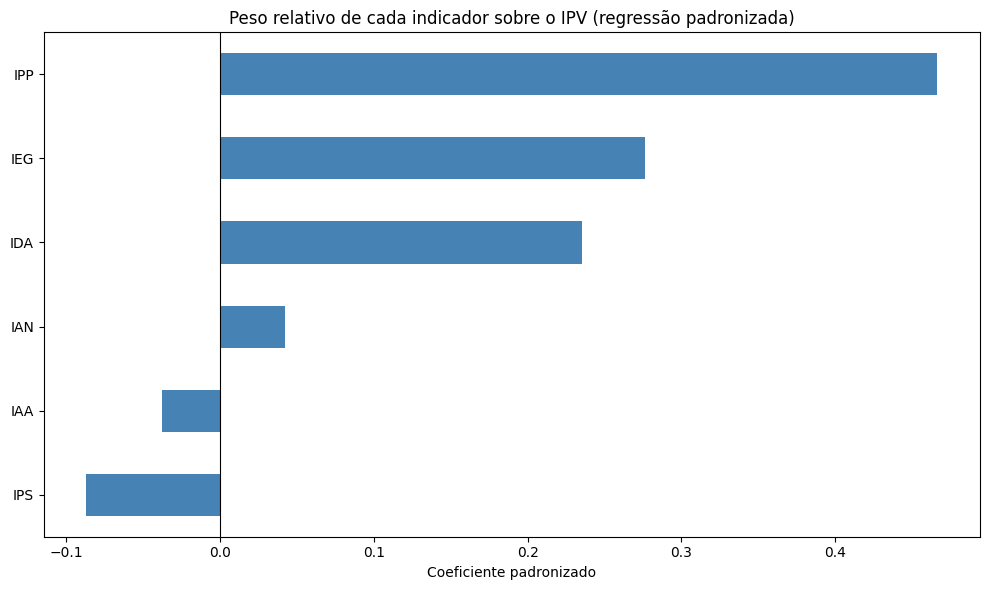

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
coeficientes.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Peso relativo de cada indicador sobre o IPV (regressão padronizada)')
ax.set_xlabel('Coeficiente padronizado')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [ ]:
preditores_inde = ['IDA', 'IEG', 'IPS', 'IPP', 'IAN', 'IAA']

dados_inde = df_long[preditores_inde + ['INDE']].dropna()
X = dados_inde[preditores_inde]
y = dados_inde['INDE']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

modelo_inde = LinearRegression()
modelo_inde.fit(X_scaled, y)

print(f"R² do modelo: {modelo_inde.score(X_scaled, y):.3f}")
print(f"N de observações: {len(dados_inde)}")

coef_inde = pd.Series(modelo_inde.coef_, index=preditores_inde).sort_values(ascending=False)
print("\nCoeficientes padronizados (peso de cada indicador no INDE):")
print(coef_inde.round(3))

# Testar combinação específica pedida na pergunta: IDA + IEG + IPS + IPP juntos, sem IAN/IAA
preditores_combo = ['IDA', 'IEG', 'IPS', 'IPP']
dados_combo = df_long[preditores_combo + ['INDE']].dropna()
X_combo = StandardScaler().fit_transform(dados_combo[preditores_combo])
modelo_combo = LinearRegression().fit(X_combo, dados_combo['INDE'])
print(f"\nR² usando só IDA+IEG+IPS+IPP: {modelo_combo.score(X_combo, dados_combo['INDE']):.3f}")
print(f"N: {len(dados_combo)}")

R² do modelo: 0.978
N de observações: 1985

Coeficientes padronizados (peso de cada indicador no INDE):
IDA    0.428
IEG    0.358
IAA    0.274
IAN    0.261
IPP    0.187
IPS    0.179
dtype: float64

R² usando só IDA+IEG+IPS+IPP: 0.823
N: 1985


In [ ]:
df_long['TOP_INDE'] = df_long.groupby('ANO')['INDE'].transform(lambda s: s >= s.quantile(0.9))

comparacao = df_long.groupby('TOP_INDE')[['IDA', 'IEG', 'IPS', 'IPP', 'IAN', 'IAA']].mean().round(2)
comparacao.index = ['Demais alunos', 'Top 10% INDE']
print(comparacao.T)

     Demais alunos  Top 10% INDE
IDA           6.13          8.59
IEG           7.78          9.52
IPS           6.19          7.14
IPP           7.47          8.32
IAN           6.97          9.16
IAA           7.78          9.19


In [ ]:
features_base = ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPV', 'INDE',
                  'DEFASAGEM', 'IDADE', 'GENERO', 'FASE', 'N_AVALIACOES',
                  'NOTA_MAT', 'NOTA_POR', 'NOTA_ING', 'ANO_INGRESSO']

pivots = {}
for col in features_base:
    pivots[col] = df_long.pivot_table(index='RA', columns='ANO', values=col,
                                        aggfunc='first').reindex(df_long['RA'].unique())

blocos = []
for ano_t, ano_t1 in [(2022, 2023), (2023, 2024)]:
    bloco = pd.DataFrame({'RA': df_long['RA'].unique(), 'ANO_BASE': ano_t})
    for col in features_base:
        bloco[col] = pivots[col][ano_t].values
    bloco['DEFASAGEM_t1'] = pivots['DEFASAGEM'][ano_t1].values
    blocos.append(bloco)

dataset_modelo = pd.concat(blocos, ignore_index=True)

dataset_modelo['RISCO_DEFASAGEM'] = (dataset_modelo['DEFASAGEM_t1'] <= -2).astype(int)

dataset_modelo['TEMPO_NA_PM'] = dataset_modelo['ANO_BASE'] - dataset_modelo['ANO_INGRESSO']

dataset_modelo = dataset_modelo.dropna(subset=['IAN', 'DEFASAGEM_t1'])

print("Shape do dataset de modelagem:", dataset_modelo.shape)
print("\nDistribuição do alvo:")
print(dataset_modelo['RISCO_DEFASAGEM'].value_counts())
print(dataset_modelo['RISCO_DEFASAGEM'].value_counts(normalize=True).round(3))

Shape do dataset de modelagem: (1365, 21)

Distribuição do alvo:
RISCO_DEFASAGEM
0    1206
1     159
Name: count, dtype: int64
RISCO_DEFASAGEM
0    0.884
1    0.116
Name: proportion, dtype: float64


In [ ]:
colunas_features = ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPV', 'INDE', 'DEFASAGEM',
                     'IDADE', 'GENERO', 'FASE', 'N_AVALIACOES', 'NOTA_MAT',
                     'NOTA_POR', 'NOTA_ING', 'TEMPO_NA_PM']

print("Nulos por feature:")
print(dataset_modelo[colunas_features].isna().sum().sort_values(ascending=False))

dataset_modelo['GENERO_COD'] = dataset_modelo['GENERO'].map({'Feminino': 0, 'Masculino': 1})

colunas_features_final = [c if c != 'GENERO' else 'GENERO_COD' for c in colunas_features]
print("\nFeatures finais:", colunas_features_final)

Nulos por feature:
NOTA_ING        956
INDE             75
IPV              72
IDA              72
NOTA_POR         72
NOTA_MAT         72
N_AVALIACOES     72
IEG              72
IPS              62
IAA              59
DEFASAGEM         0
IAN               0
FASE              0
GENERO            0
IDADE             0
TEMPO_NA_PM       0
dtype: int64

Features finais: ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPV', 'INDE', 'DEFASAGEM', 'IDADE', 'GENERO_COD', 'FASE', 'N_AVALIACOES', 'NOTA_MAT', 'NOTA_POR', 'NOTA_ING', 'TEMPO_NA_PM']


In [ ]:
from sklearn.model_selection import train_test_split

ras_unicos = dataset_modelo['RA'].unique()
ras_treino, ras_teste = train_test_split(ras_unicos, test_size=0.25, random_state=42)

df_treino = dataset_modelo[dataset_modelo['RA'].isin(ras_treino)].copy()
df_teste = dataset_modelo[dataset_modelo['RA'].isin(ras_teste)].copy()

print("Treino:", df_treino.shape, "- % positivos:", round(df_treino['RISCO_DEFASAGEM'].mean()*100, 1))
print("Teste:", df_teste.shape, "- % positivos:", round(df_teste['RISCO_DEFASAGEM'].mean()*100, 1))

X_treino = df_treino[colunas_features_final].copy()
X_teste = df_teste[colunas_features_final].copy()

medianas_treino = X_treino.median()
X_treino = X_treino.fillna(medianas_treino)
X_teste = X_teste.fillna(medianas_treino)

y_treino = df_treino['RISCO_DEFASAGEM']
y_teste = df_teste['RISCO_DEFASAGEM']

print("\nNulos restantes no treino:", X_treino.isna().sum().sum())
print("Nulos restantes no teste:", X_teste.isna().sum().sum())

Treino: (1016, 22) - % positivos: 11.3
Teste: (349, 22) - % positivos: 12.6

Nulos restantes no treino: 0
Nulos restantes no teste: 0


In [ ]:
colunas_features_final.remove('NOTA_ING')
print("Features finais (ajustadas):", colunas_features_final)

X_treino = df_treino[colunas_features_final].fillna(medianas_treino[colunas_features_final])
X_teste = df_teste[colunas_features_final].fillna(medianas_treino[colunas_features_final])

print("\nShape X_treino:", X_treino.shape)
print("Shape X_teste:", X_teste.shape)

Features finais (ajustadas): ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPV', 'INDE', 'DEFASAGEM', 'IDADE', 'GENERO_COD', 'FASE', 'N_AVALIACOES', 'NOTA_MAT', 'NOTA_POR', 'TEMPO_NA_PM']

Shape X_treino: (1016, 15)
Shape X_teste: (349, 15)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_treino_scaled = scaler.fit_transform(X_treino)
X_teste_scaled = scaler.transform(X_teste)

modelo_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
modelo_lr.fit(X_treino_scaled, y_treino)

modelo_rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                     max_depth=6, min_samples_leaf=10, random_state=42)
modelo_rf.fit(X_treino, y_treino)

print("Modelos treinados.")

Modelos treinados.


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

for nome, modelo, X_t in [('Regressão Logística', modelo_lr, X_teste_scaled),
                            ('Random Forest', modelo_rf, X_teste)]:
    y_pred = modelo.predict(X_t)
    y_proba = modelo.predict_proba(X_t)[:, 1]

    print(f"\n{'='*50}\n{nome}\n{'='*50}")
    print(classification_report(y_teste, y_pred, target_names=['Sem risco', 'Em risco']))
    print(f"AUC-ROC: {roc_auc_score(y_teste, y_proba):.3f}")
    print("Matriz de confusão:")
    print(confusion_matrix(y_teste, y_pred))


Regressão Logística
              precision    recall  f1-score   support

   Sem risco       0.97      0.77      0.86       305
    Em risco       0.34      0.82      0.48        44

    accuracy                           0.77       349
   macro avg       0.65      0.79      0.67       349
weighted avg       0.89      0.77      0.81       349

AUC-ROC: 0.890
Matriz de confusão:
[[234  71]
 [  8  36]]

Random Forest
              precision    recall  f1-score   support

   Sem risco       0.97      0.83      0.89       305
    Em risco       0.41      0.82      0.55        44

    accuracy                           0.83       349
   macro avg       0.69      0.82      0.72       349
weighted avg       0.90      0.83      0.85       349

AUC-ROC: 0.902
Matriz de confusão:
[[253  52]
 [  8  36]]


DEFASAGEM       0.203
IAN             0.163
IPV             0.145
INDE            0.117
NOTA_POR        0.071
IEG             0.069
IDA             0.047
FASE            0.045
IDADE           0.039
NOTA_MAT        0.035
N_AVALIACOES    0.022
IAA             0.018
IPS             0.013
TEMPO_NA_PM     0.009
GENERO_COD      0.003
dtype: float64


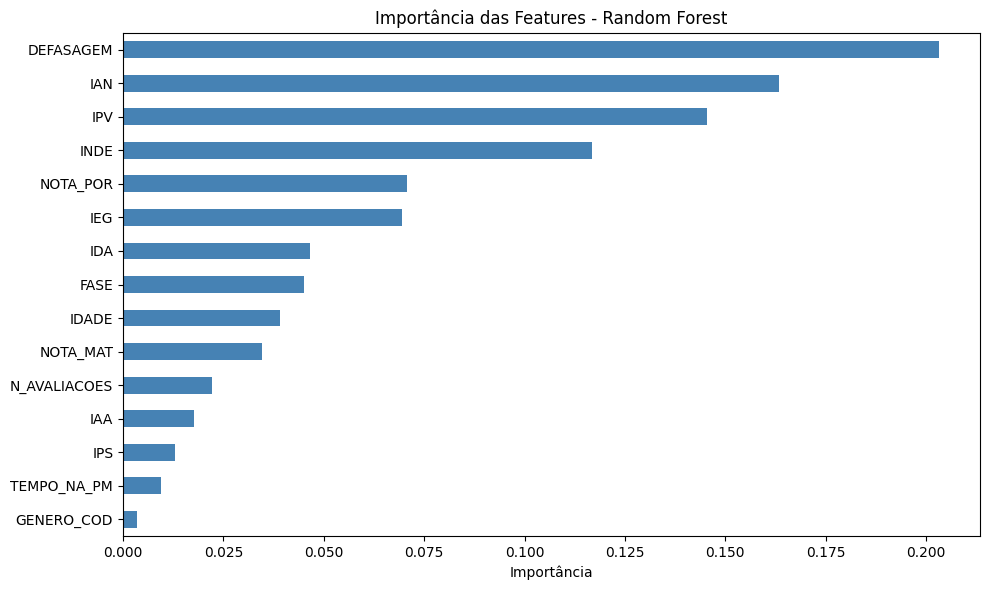

In [ ]:
importancias = pd.Series(modelo_rf.feature_importances_, index=colunas_features_final).sort_values(ascending=False)
print(importancias.round(3))

fig, ax = plt.subplots(figsize=(10, 6))
importancias.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Importância das Features - Random Forest')
ax.set_xlabel('Importância')
plt.tight_layout()
plt.show()

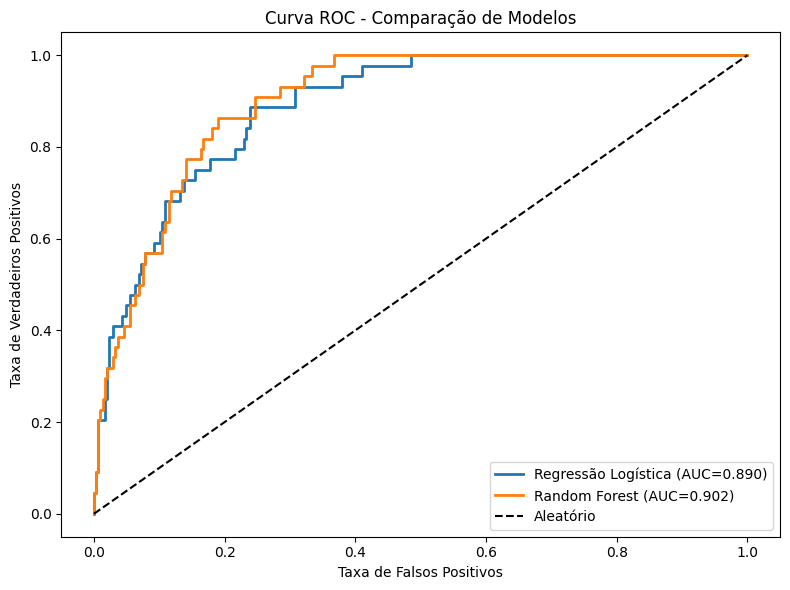

In [ ]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))
for nome, modelo, X_t in [('Regressão Logística', modelo_lr, X_teste_scaled),
                            ('Random Forest', modelo_rf, X_teste)]:
    y_proba = modelo.predict_proba(X_t)[:, 1]
    fpr, tpr, _ = roc_curve(y_teste, y_proba)
    auc = roc_auc_score(y_teste, y_proba)
    ax.plot(fpr, tpr, label=f'{nome} (AUC={auc:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Aleatório')
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curva ROC - Comparação de Modelos')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
import joblib
import os

pasta_modelo = '/content/drive/MyDrive/FIAP/Tech Challenge 5/Datathon/modelo'
os.makedirs(pasta_modelo, exist_ok=True)

joblib.dump(modelo_rf, f'{pasta_modelo}/modelo_risco_defasagem.pkl')
joblib.dump(medianas_treino[colunas_features_final], f'{pasta_modelo}/medianas_features.pkl')
joblib.dump(colunas_features_final, f'{pasta_modelo}/lista_features.pkl')

print("Modelo e artefatos salvos em:", pasta_modelo)
print("Features esperadas pelo modelo:", colunas_features_final)

Modelo e artefatos salvos em: /content/drive/MyDrive/FIAP/Tech Challenge 5/Datathon/modelo
Features esperadas pelo modelo: ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPV', 'INDE', 'DEFASAGEM', 'IDADE', 'GENERO_COD', 'FASE', 'N_AVALIACOES', 'NOTA_MAT', 'NOTA_POR', 'TEMPO_NA_PM']


In [ ]:
def prever_risco(dados_aluno: dict, modelo, features_esperadas, medianas):
    linha = pd.Series({f: dados_aluno.get(f, np.nan) for f in features_esperadas})
    linha = linha.fillna(medianas)
    X = pd.DataFrame([linha[features_esperadas].values], columns=features_esperadas)
    proba = modelo.predict_proba(X)[0, 1]
    classe = modelo.predict(X)[0]
    return classe, proba

# Reteste
classe, proba = prever_risco(exemplo, modelo_rf, colunas_features_final, medianas_treino[colunas_features_final])
print(f"Classe predita: {'Em risco' if classe == 1 else 'Sem risco'}")
print(f"Probabilidade: {proba:.1%}")

Classe predita: Sem risco
Probabilidade: 24.0%


In [ ]:
ordem_pedra = {'Quartzo': 1, 'Ágata': 2, 'Ametista': 3, 'Topázio': 4}

pivot_pedra = df_long.pivot_table(index='RA', columns='ANO', values='PEDRA', aggfunc='first')

def classificar_transicao(p_t, p_t1):
    if pd.isna(p_t) or pd.isna(p_t1):
        return np.nan
    rank_t, rank_t1 = ordem_pedra.get(p_t), ordem_pedra.get(p_t1)
    if rank_t is None or rank_t1 is None:
        return np.nan
    if rank_t1 > rank_t:
        return 'Subiu'
    elif rank_t1 < rank_t:
        return 'Desceu'
    else:
        return 'Manteve'

resultados_transicao = {}
for ano_t, ano_t1 in [(2022, 2023), (2023, 2024)]:
    trans = pivot_pedra.apply(lambda row: classificar_transicao(row[ano_t], row[ano_t1]), axis=1)
    resultados_transicao[f'{ano_t}→{ano_t1}'] = trans.value_counts(normalize=True).round(3) * 100

tabela_transicoes = pd.DataFrame(resultados_transicao)
print(tabela_transicoes)

for ano_t, ano_t1 in [(2022, 2023), (2023, 2024)]:
    print(f"\n=== Matriz de transição {ano_t} → {ano_t1} ===")
    crosstab = pd.crosstab(pivot_pedra[ano_t], pivot_pedra[ano_t1], normalize='index') * 100
    ordem_labels = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
    crosstab = crosstab.reindex(index=ordem_labels, columns=ordem_labels)
    print(crosstab.round(1))

         2022→2023  2023→2024
Manteve       51.2       50.0
Desceu        24.4       25.8
Subiu         24.4       24.2

=== Matriz de transição 2022 → 2023 ===
2023      Quartzo  Ágata  Ametista  Topázio
2022                                       
Quartzo      35.4   54.2      10.4      0.0
Ágata        16.6   49.0      30.6      3.8
Ametista      3.1   22.7      52.9     21.2
Topázio       0.9    5.5      36.4     57.3

=== Matriz de transição 2023 → 2024 ===
2024      Quartzo  Ágata  Ametista  Topázio
2023                                       
Quartzo      47.6   40.5      11.9      0.0
Ágata        20.4   44.7      27.0      7.9
Ametista      7.3   19.7      43.3     29.7
Topázio       0.5    4.3      29.3     65.8


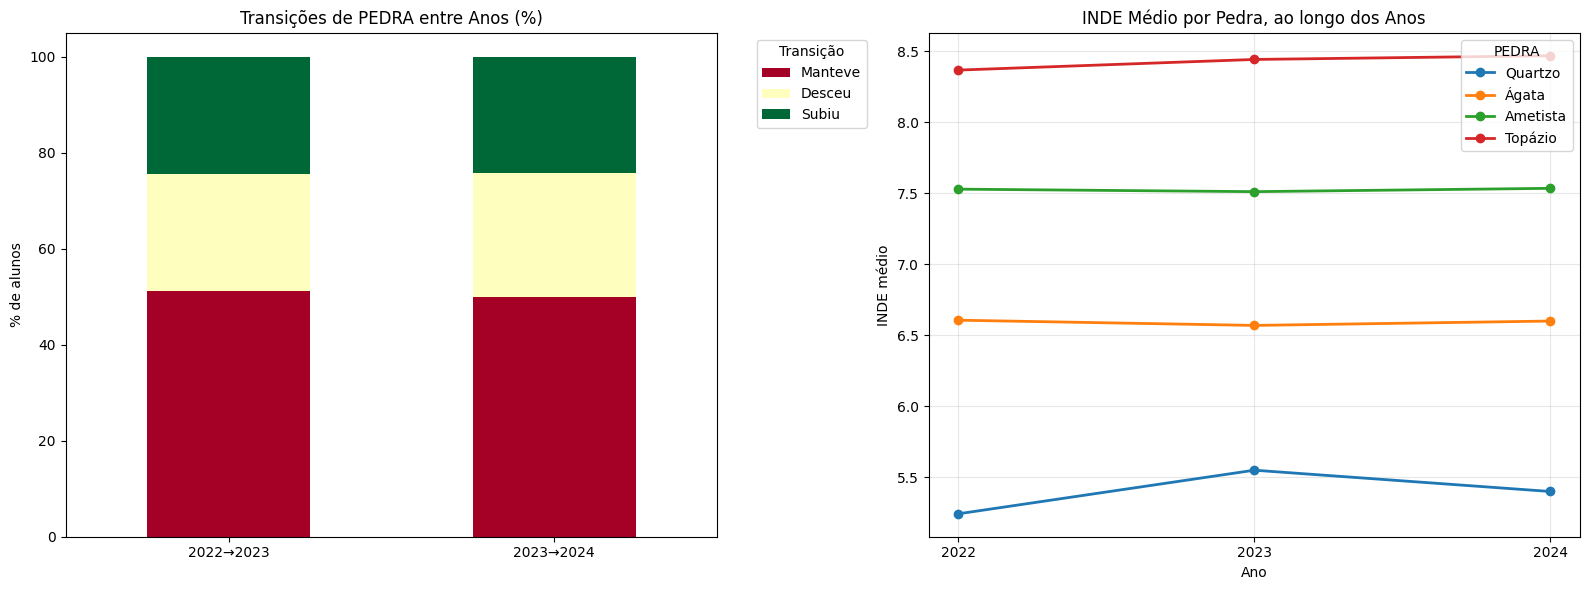

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

tabela_transicoes.T.plot(kind='bar', stacked=True, ax=axes[0], colormap='RdYlGn')
axes[0].set_title('Transições de PEDRA entre Anos (%)')
axes[0].set_ylabel('% de alunos')
axes[0].legend(title='Transição', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=0)

inde_por_pedra_ano = df_long.groupby(['ANO', 'PEDRA'])['INDE'].mean().unstack()
ordem_labels = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
inde_por_pedra_ano = inde_por_pedra_ano[ordem_labels]
inde_por_pedra_ano.plot(marker='o', ax=axes[1], linewidth=2)
axes[1].set_title('INDE Médio por Pedra, ao longo dos Anos')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('INDE médio')
axes[1].set_xticks(inde_por_pedra_ano.index)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
def classificar_instituicao(valor):
    if pd.isna(valor):
        return np.nan
    v = str(valor).strip()
    if v in ['Escola Pública', 'Pública']:
        return 'Pública'
    if v in ['Concluiu o 3º EM', 'Bolsista Universitário *Formado (a)', 'Nenhuma das opções acima']:
        return 'Outro/Concluinte'
    if 'Privada' in v or v in ['Rede Decisão', 'Escola JP II']:
        return 'Privada'
    return 'Outro/Concluinte'

df_long['TIPO_INSTITUICAO'] = df_long['INSTITUICAO_ENSINO'].apply(classificar_instituicao)

print(df_long['TIPO_INSTITUICAO'].value_counts(dropna=False))

subset_inst = df_long[df_long['TIPO_INSTITUICAO'].isin(['Pública', 'Privada'])]

print("\nMédias por tipo de instituição:")
print(subset_inst.groupby('TIPO_INSTITUICAO')[['INDE', 'IAN', 'IDA', 'IEG', 'DEFASAGEM']].mean().round(2))

print("\n% de alunos com defasagem moderada/severa, por tipo:")
print(subset_inst.groupby('TIPO_INSTITUICAO')['CLASSIF_DEFASAGEM'].apply(
    lambda s: (s == 'Moderada/Severamente defasado').mean() * 100
).round(1))

# Teste estatístico
from scipy.stats import ttest_ind
pub = subset_inst[subset_inst['TIPO_INSTITUICAO'] == 'Pública']['INDE'].dropna()
priv = subset_inst[subset_inst['TIPO_INSTITUICAO'] == 'Privada']['INDE'].dropna()
t_stat, p_val = ttest_ind(pub, priv, equal_var=False)
print(f"\nTeste t (INDE Pública vs Privada): t={t_stat:.2f}, p-valor={p_val:.4f}")

TIPO_INSTITUICAO
Pública             2474
Privada              526
Outro/Concluinte      29
NaN                    1
Name: count, dtype: int64

Médias por tipo de instituição:
                  INDE   IAN   IDA   IEG  DEFASAGEM
TIPO_INSTITUICAO                                   
Privada           7.73  8.85  7.00  6.99      -0.01
Pública           7.20  6.81  6.28  8.17      -0.78

% de alunos com defasagem moderada/severa, por tipo:
TIPO_INSTITUICAO
Privada     5.5
Pública    15.9
Name: CLASSIF_DEFASAGEM, dtype: float64

Teste t (INDE Pública vs Privada): t=-9.60, p-valor=0.0000


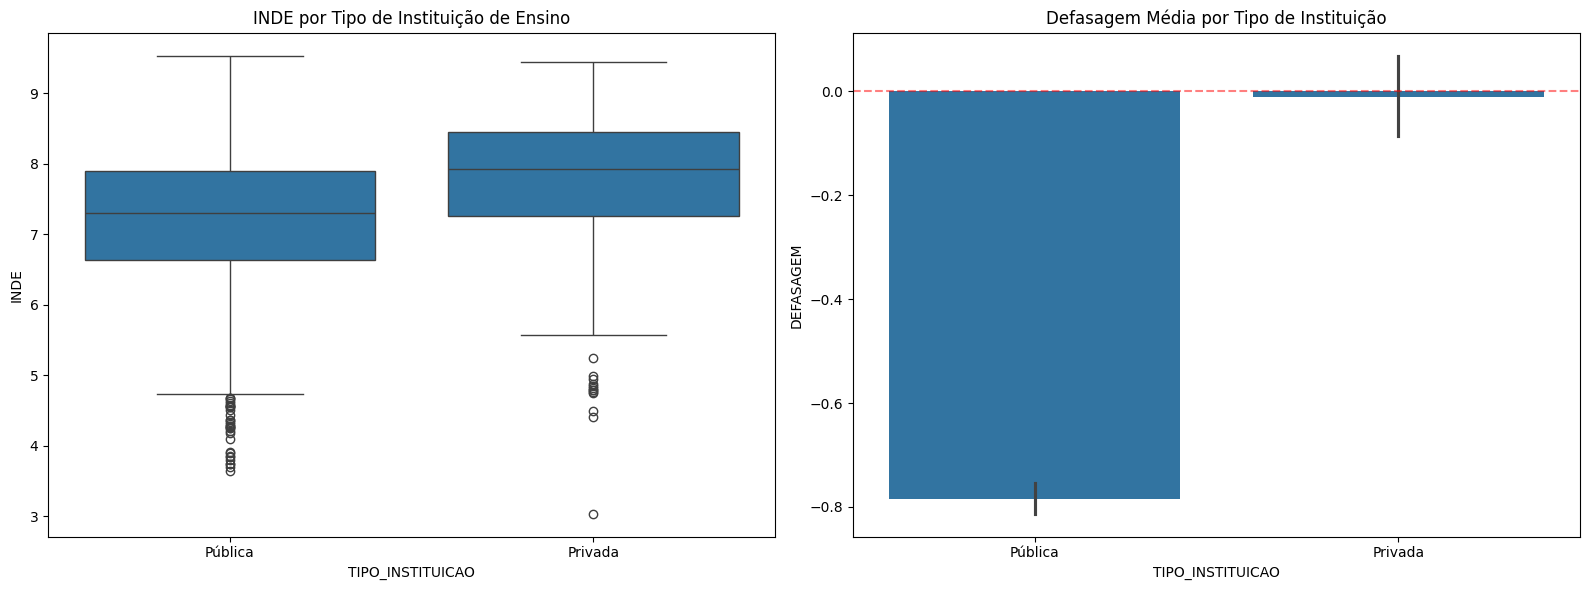

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=subset_inst, x='TIPO_INSTITUICAO', y='INDE', ax=axes[0])
axes[0].set_title('INDE por Tipo de Instituição de Ensino')

sns.barplot(data=subset_inst, x='TIPO_INSTITUICAO', y='DEFASAGEM',
            estimator=np.mean, errorbar='ci', ax=axes[1])
axes[1].set_title('Defasagem Média por Tipo de Instituição')
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()